## 1. Introduction

### Problem Statement: Cross-Asset Portfolio Optimization

Problem Statement 2: Cross-Asset Portfolio Optimization.
The objective is to construct a diversified, systematic investment portfolio using multiple asset classes such as equities, indices, and commodities.

Financial markets behave differently under varying conditions such as bull markets, bear markets, and high-volatility regimes.
By combining assets that exhibit different risk and return characteristics, we aim to reduce overall portfolio risk while maintaining strong risk-adjusted returns.

The goal is to design a portfolio that delivers:
- High risk-adjusted returns (Sharpe Ratio)
- Controlled drawdowns
- Stable performance across market regimes

**objective**: maximize risk-adjusted returns while controlling drawdowns


### Model Overview

The proposed approach is a systematic portfolio allocation framework based on historical return and risk characteristics of multiple assets.
We compute asset returns, estimate risk using volatility and correlations, and construct an optimized portfolio using quantitative allocation techniques.

The strategy is evaluated using a backtesting framework and assessed through standard portfolio performance metrics such as Sharpe Ratio, Sortino Ratio, volatility, and maximum drawdown.


### Motivation

Diversification across asset classes helps reduce portfolio sensitivity to extreme market movements.
Equities, indices, and commodities often respond differently to macroeconomic and market shocks.
By leveraging these differences, the portfolio aims to achieve smoother equity curves and improved risk-adjusted performance.


In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

In [2]:
# data loading 
files = {
    'AMZN' : 'Amazon.com Stock Price History.csv',
    'APPL' : 'Apple Stock Price History.csv',
    'CRUDE' : 'Crude Oil WTI Futures Historical Data.csv' ,
    'GOLD' : 'Gold Futures Historical Data.csv',
    'SILVER' : 'Silver Futures Historical Data.csv',
    'META' : 'Meta Platforms Stock Price History.csv', 
    'MSFT' : 'Microsoft Stock Price History.csv',
    'TESLA' : 'Tesla Stock Price History.csv',
    'NVDA' : 'NVIDIA Stock Price History.csv',
    'NASDAQ' : 'Nasdaq 100 Historical Data.csv'
}

data = {}

for asset, file in files.items():
    df = pd.read_csv(file)
    data[asset] = df

In [3]:
for asset, df in data.items():
    print(f'{asset} => shape : {df.shape}')

AMZN => shape : (5000, 7)
APPL => shape : (5000, 7)
CRUDE => shape : (5000, 7)
GOLD => shape : (5000, 7)
SILVER => shape : (5000, 7)
META => shape : (3143, 7)
MSFT => shape : (5000, 7)
TESLA => shape : (3618, 7)
NVDA => shape : (5000, 7)
NASDAQ => shape : (5000, 7)


In [4]:
# data types + null value discription
a = 1
for asset, df in data.items():
    print(f'{a}. {asset}\n')
    print(f'{asset} => description : {df.info()}\n')
    print('===========================================================================================\n')
    a += 1

# price = closing price

1. AMZN

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      5000 non-null   object 
 1   Price     5000 non-null   float64
 2   Open      5000 non-null   float64
 3   High      5000 non-null   float64
 4   Low       5000 non-null   float64
 5   Vol.      5000 non-null   object 
 6   Change %  5000 non-null   object 
dtypes: float64(4), object(3)
memory usage: 273.6+ KB
AMZN => description : None


2. APPL

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      5000 non-null   object 
 1   Price     5000 non-null   float64
 2   Open      5000 non-null   float64
 3   High      5000 non-null   float64
 4   Low       5000 non-null   float64
 5   Vol.      4999 non-null   object 
 6   Change %  5000 non-

## Data Cleaning

In [5]:
# data type conversions 


# Timestamp datatype
for asset, df in data.items() :
    df.columns = df.columns.str.lower()
    if 'date' in df.columns :
        df['date'] = pd.to_datetime(df['date'])
        df.rename(columns={'date':'timestamp'}, inplace=True)
    df.sort_values('timestamp' ,inplace=True)
    df.reset_index(drop=True, inplace=True)
    data[asset] = df
    
# Vol. datatype 
for asset, df in data.items():
    if 'vol.' in df.columns:
        df['vol.'] = (
            df['vol.']
            .astype(str)
            .str.replace(',', '', regex=False)
            .str.replace('K', 'e3', regex=False)
            .str.replace('M', 'e6', regex=False)
            .str.replace('-', '', regex=False)
            .str.replace('—', '', regex=False)
        )

        df['vol.'] = pd.to_numeric(df['vol.'], errors='coerce')
    data[asset] = df

# change % datatype
for asset, df in data.items():
    if 'change %' in df.columns:
        df['change %'] = (
            df['change %']
            .astype(str)
            .str.replace('%', '', regex=False)
            .str.replace(',', '', regex=False)   
            .str.replace('—', '', regex=False)
            .str.replace('-', '', regex=False)
        )
        df['change %'] = pd.to_numeric(df['change %'], errors='coerce')
    data[asset] = df

# price, open , low , close 
for asset, df in data.items():
    if 'price' in df.columns:
        df.rename(columns={'price': 'close'}, inplace=True)
    for col in ['open', 'close', 'low', 'high']:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.replace(',', '', regex=False)
                .replace('', np.nan)
            )
            df[col] = pd.to_numeric(df[col], errors='coerce')
        data[asset] = df
    

In [6]:
for asset, df in data.items():
    print(f'{asset} => Total Null Values:\n\n{df.isna().sum()}\n')
    print('===========================================================================================\n')


AMZN => Total Null Values:

timestamp    0
close        0
open         0
high         0
low          0
vol.         8
change %     0
dtype: int64


APPL => Total Null Values:

timestamp      0
close          0
open           0
high           0
low            0
vol.         389
change %       0
dtype: int64


CRUDE => Total Null Values:

timestamp      0
close          0
open           0
high           0
low            0
vol.         127
change %       0
dtype: int64


GOLD => Total Null Values:

timestamp    0
close        0
open         0
high         0
low          0
vol.         3
change %     0
dtype: int64


SILVER => Total Null Values:

timestamp     0
close         0
open          0
high          0
low           0
vol.         29
change %      0
dtype: int64


META => Total Null Values:

timestamp    0
close        0
open         0
high         0
low          0
vol.         0
change %     0
dtype: int64


MSFT => Total Null Values:

timestamp    0
close        0
open         0
h

In [7]:
# missing value handling
for asset, df in data.items():
    df.ffill(inplace=True)
    df.bfill(inplace=True)
    data[asset] = df.copy()


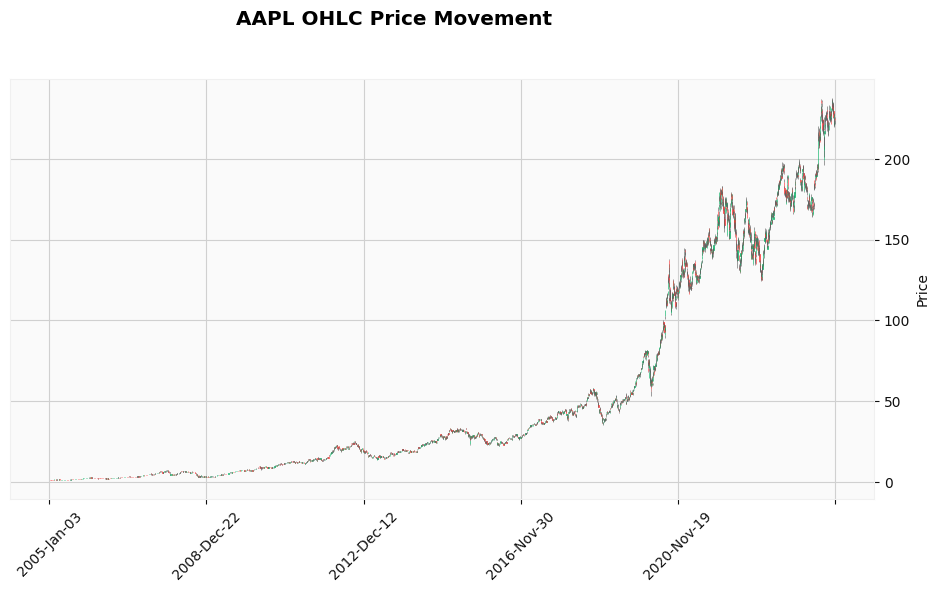

In [8]:
import mplfinance as mpf
# Representative asset (Apple)
ohlc_df = data['APPL'][['timestamp', 'open', 'high', 'low', 'close']].copy()
ohlc_df.set_index('timestamp', inplace=True)

mpf.plot(
    ohlc_df,
    type='candle',
    style='yahoo',
    title='AAPL OHLC Price Movement',
    ylabel='Price',
    volume=False,
    figsize=(12,6)
)


### OHLC Price Visualization

An OHLC (Open-High-Low-Close) candlestick chart is used to visually inspect
price behavior and market structure before return computation. This helps
identify trends, volatility clustering, and potential anomalies in the raw data.

### Observations

- The OHLC chart shows a strong long-term upward trend, indicating sustained growth
  in the underlying asset over the full historical period.
- Periods of sharp price declines and heightened intraday ranges are visible during
  major market stress events, particularly around the 2008 financial crisis and the
  2020 COVID-19 market shock.
- Volatility clustering is evident, with high-volatility phases followed by relatively
  stable periods, suggesting regime-dependent market behavior.
- Post-crisis recovery phases demonstrate rapid price rebounds, reflecting strong
  momentum and resilience in the asset.

### Conclusion

The OHLC analysis confirms that the raw price data is structurally sound and exhibits
realistic market behavior across multiple economic cycles. The presence of both
prolonged trends and volatility spikes justifies the use of return-based modeling
and volatility-aware portfolio construction techniques. This visual inspection
supports the subsequent transformation of price data into returns and risk metrics
for systematic portfolio optimization.


In [9]:
for asset, df in data.items():
    print(f"\n{asset}")
    print(df.dtypes)



AMZN
timestamp    datetime64[ns]
close               float64
open                float64
high                float64
low                 float64
vol.                float64
change %            float64
dtype: object

APPL
timestamp    datetime64[ns]
close               float64
open                float64
high                float64
low                 float64
vol.                float64
change %            float64
dtype: object

CRUDE
timestamp    datetime64[ns]
close               float64
open                float64
high                float64
low                 float64
vol.                float64
change %            float64
dtype: object

GOLD
timestamp    datetime64[ns]
close               float64
open                float64
high                float64
low                 float64
vol.                float64
change %            float64
dtype: object

SILVER
timestamp    datetime64[ns]
close               float64
open                float64
high                float64
low            

In [10]:
# return calculation
for asset, df in data.items():
    df['return'] = df['close'].pct_change()
    data[asset] = df

## Price Movement Plot : APPLE [sample asset]

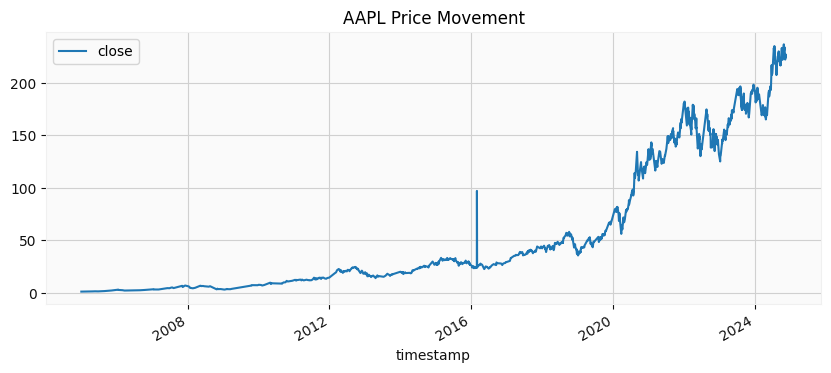

In [11]:
data['APPL'].plot(x='timestamp', y='close', title='AAPL Price Movement', figsize=(10,4))
plt.show()


**Observations :** 

1. Strong long-term uptrend from 2006 to 2024 - confirms AAPL as a structural growth stock.
2. Post-2019 acceleration indicates:

    a. Strong earnings growth
    
    b. Market dominance + tech rally
    
3. Sharp spike around 2016 is likely due to:
   
    a. Stock split / data anomaly / adjustment issue, should be flagged during preprocessing (important         for modeling)
   
5. Drawdowns exist, but trend recovery is fast, indicating resilience.

Conclusion :

AAPL behaves as a low-to-medium volatility growth equity, suitable as a core portfolio holding.

## Return Distribution

In [12]:
returns_df = pd.DataFrame()

for asset, df in data.items():
    returns_df[asset] = df.set_index('timestamp')['return']

returns_df = returns_df.replace([np.inf, -np.inf], np.nan)
returns_df.dropna(inplace=True)


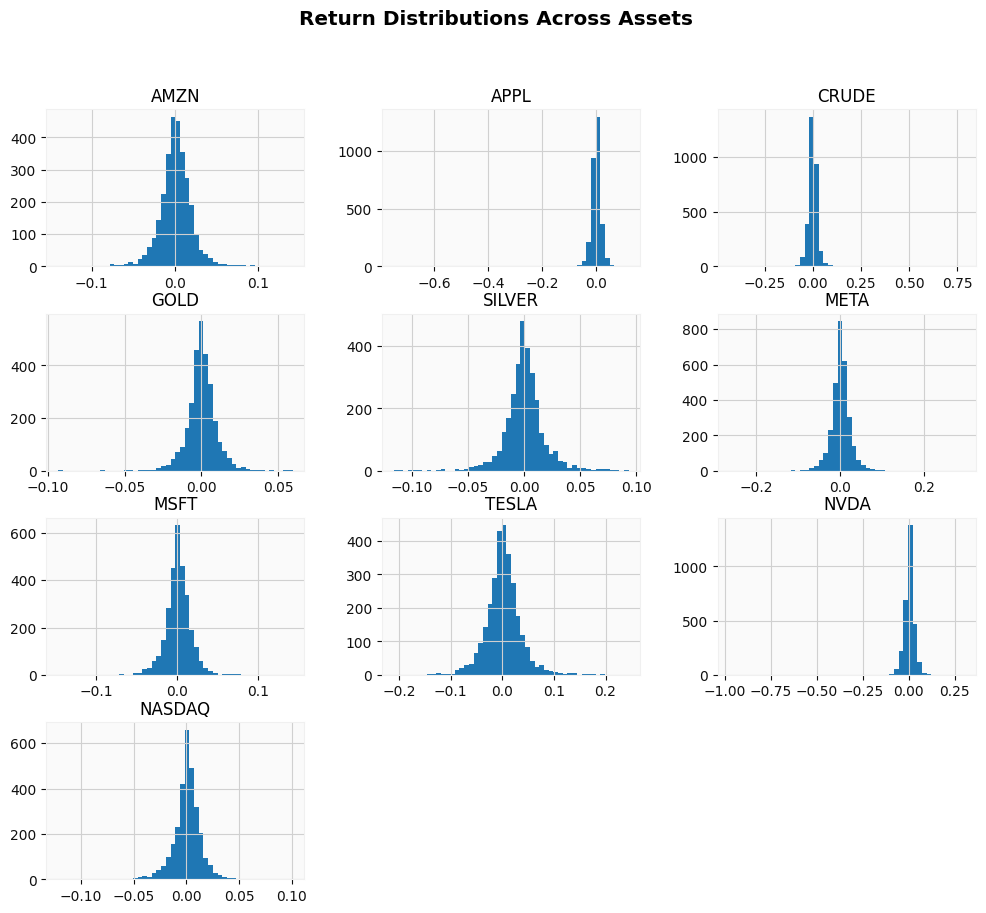

In [13]:
returns_df.hist(figsize=(12,10), bins=50)
plt.suptitle("Return Distributions Across Assets")
plt.show()

**Observations :**

**A. Common Patterns**

1. Most assets show bell-shaped distributions centered near 0
2. Returns are not perfectly normal (fat tails exist)

**B. Asset-wise Observations**

1. *Tech stocks (AAPL, MSFT, META, NVDA, TESLA):*

    a. Higher variance
    
    b. Fatter tails ==> higher upside and downside risk

2. *TESLA & NVDA:*

    a. Widest spreads ==> highest volatility

3. *NASDAQ:*

    a. Narrower than individual tech stocks ==> diversification benefit

4. *GOLD & SILVER:*

    a. Tighter distributions

    b. More symmetric ==> defensive assets

5. *CRUDE:*

    a. Highly peaked + fat tails ==> event-driven volatility

**Conclusions:**

1. Tech = return generators
2. Commodities = volatility hedgers

## Rolling Volatility

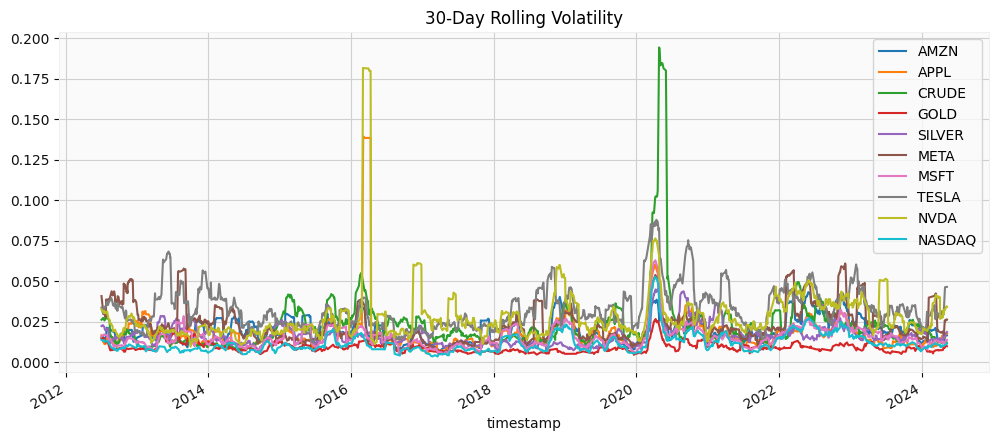

In [14]:
# rolling volatility measures an asset's risk by calculating its price fluctuation (standard deviation) 
# over a moving, shorter time window (like 20 or 30 days)

rolling_vol = returns_df.rolling(30).std()

rolling_vol.plot(figsize=(12,5))
plt.title("30-Day Rolling Volatility")
plt.show()


**Observations :**

1. Volatility clustering is clearly visible which confirms financial time-series behavior.
2. Major spikes around 2016 & 2020
3. 2016: oil shock / macro events
4. 2020: COVID crash (systemic risk)
5. CRUDE shows the largest volatility spikes extreme sensitivity to macro shocks.
6. TESLA & META : Consistently higher volatility than MSFT/AAPL.
7. GOLD & SILVER: Lowest and most stable volatility.

**Conclusions :**

Rolling volatility validates risk regimes useful for:
1. regime-switching models
2. dynamic position sizing
3. risk parity portfolios

## Feature Engineering - Cross Asset

In [15]:
print(returns_df.head())

                AMZN      APPL     CRUDE      GOLD    SILVER      META  \
timestamp                                                                
2012-05-21  0.020580  0.058606  0.011915 -0.002010 -0.013721 -0.109861   
2012-05-22 -0.012832 -0.007980 -0.009830 -0.007616 -0.005014 -0.089039   
2012-05-23  0.008357  0.024635 -0.019201 -0.017887 -0.023422  0.032258   
2012-05-24 -0.009208 -0.009323  0.008454  0.005877  0.023184  0.032188   
2012-05-25 -0.011152 -0.005448  0.002206  0.007319  0.008133 -0.033909   

                MSFT     TESLA      NVDA    NASDAQ  
timestamp                                           
2012-05-21  0.016399  0.043478  0.033333  0.026992  
2012-05-22  0.000336  0.067708 -0.032258 -0.002448  
2012-05-23 -0.021841  0.009756  0.033333  0.003103  
2012-05-24 -0.001374 -0.024155 -0.032258 -0.006176  
2012-05-25 -0.000344 -0.014851  0.033333 -0.001699  


In [16]:
print(returns_df.nunique())

AMZN      2937
APPL      2941
CRUDE     2976
GOLD      2952
SILVER    2961
META      2971
MSFT      2953
TESLA     2917
NVDA      1997
NASDAQ    2983
dtype: int64


In [17]:
print(returns_df.isna().sum())

AMZN      0
APPL      0
CRUDE     0
GOLD      0
SILVER    0
META      0
MSFT      0
TESLA     0
NVDA      0
NASDAQ    0
dtype: int64


### Correlation and Diversification

Correlation measures the degree to which asset returns move together.
In portfolio construction, diversification benefits arise when assets
exhibit low or imperfect correlation.

Assets with high positive correlation tend to experience gains and losses
simultaneously, offering limited risk reduction when combined. In contrast,
assets with low or negative correlation help smooth portfolio returns by
offsetting losses across market conditions.

By analyzing the correlation matrix across equities, indices, and commodities,
we identify diversification opportunities and reduce concentration risk.
This insight directly informs the portfolio construction process, ensuring
that risk is distributed across heterogeneous assets rather than driven by
a single market factor.

Lower cross-asset correlation improves portfolio stability without
necessarily sacrificing expected returns.


In [18]:
# Returns and volatility were aligned on a common time index to ensure consistency across features.
valid_index = rolling_vol.dropna().index
returns_aligned = returns_df.loc[valid_index]
rolling_vol_aligned = rolling_vol.loc[valid_index]

corr_matrix = returns_aligned.corr()
corr_matrix


,AMZN,APPL,CRUDE,GOLD,SILVER,META,MSFT,TESLA,NVDA,NASDAQ
AMZN,1.000000,0.391441,0.111323,0.018287,0.075300,0.510961,0.595611,0.361110,0.410021,0.726834
APPL,0.391441,1.000000,0.107446,0.022808,0.079638,0.351212,0.485830,0.291056,0.659074,0.625790
CRUDE,0.111323,0.107446,1.000000,0.122004,0.177269,0.103039,0.164175,0.142965,0.097656,0.198511
GOLD,0.018287,0.022808,0.122004,1.000000,0.797232,0.015664,0.023396,0.046281,0.002430,0.037247
SILVER,0.075300,0.079638,0.177269,0.797232,1.000000,0.057795,0.094442,0.104443,0.053019,0.126286
META,0.510961,0.351212,0.103039,0.015664,0.057795,1.000000,0.479252,0.284884,0.358570,0.624545
MSFT,0.595611,0.485830,0.164175,0.023396,0.094442,0.479252,1.000000,0.360272,0.488660,0.832584
TESLA,0.361110,0.291056,0.142965,0.046281,0.104443,0.284884,0.360272,1.000000,0.314090,0.508146
NVDA,0.410021,0.659074,0.097656,0.002430,0.053019,0.358570,0.488660,0.314090,1.000000,0.604253
NASDAQ,0.726834,0.625790,0.198511,0.037247,0.126286,0.624545,0.832584,0.508146,0.604253,1.000000


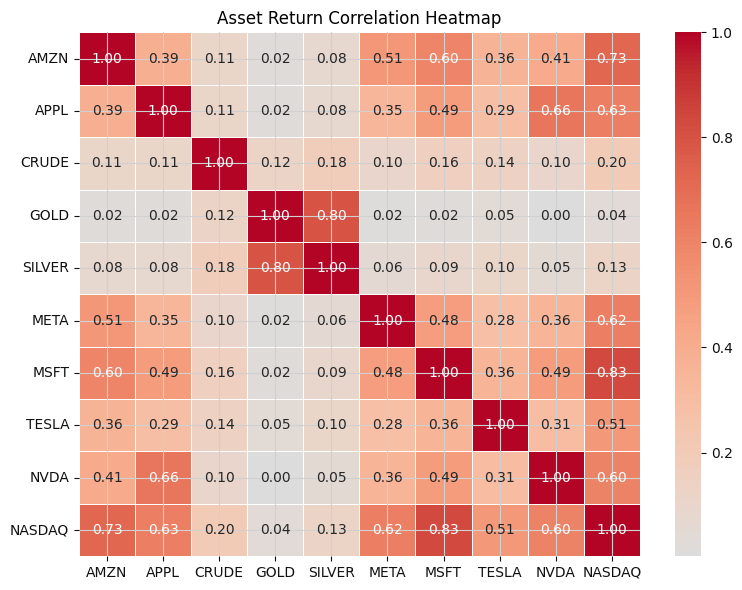

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Asset Return Correlation Heatmap")
plt.tight_layout()
plt.show()


**Heatmap – Conclusion**

1. The correlation heatmap clearly shows strong clustering among *technology stocks*.

2. They tend to move together and are driven by common market factors.

3. The **NASDAQ index exhibits the highest correlations with major tech stocks**, reinforcing its role as a market proxy for the technology sector.

4. In contrast, **Gold and Silver show near-zero correlations with equities**, highlighting their effectiveness as diversification and risk-hedging instruments.

5. **Crude oil remains weakly correlated with both equities and metals**, behaving as an independent macro-sensitive asset.

6. Overall, the heatmap confirms that sector concentration increases portfolio risk, while cross-asset allocation improves diversification.

## 4. Strategy / Model Design

### Risk Parity Portfolio Construction

The portfolio is constructed using a **risk parity strategy**, which allocates
capital such that each asset contributes equally to the overall portfolio risk.
Unlike return-weighted approaches, risk parity focuses on balancing volatility
exposure, leading to more stable performance across market regimes.

### Mathematical Formulation

Let σᵢ denote the historical volatility of asset *i*.  
Portfolio weights are assigned inversely proportional to volatility:

wᵢ ∝ 1 / σᵢ

The weights are then normalized to ensure full capital allocation:

wᵢ = (1 / σᵢ) / Σⱼ (1 / σⱼ)

This formulation ensures that assets with higher volatility receive lower weights,
while more stable assets receive higher allocations.

### Risk Management Rationale

By equalizing risk contributions rather than capital allocation, the strategy
reduces concentration risk and limits portfolio sensitivity to highly volatile
assets. This makes the approach robust during periods of market stress and
volatility spikes.

### Portfolio Constraints

The portfolio construction is subject to the following constraints:
- **Fully invested**: The sum of all portfolio weights equals 1.
- **Long-only**: No short selling is allowed.
- **No leverage**: Portfolio exposure does not exceed available capital.
- **Static allocation**: Weights are computed using historical volatility and
  held constant during the backtest period.


## Portfolio Construction 

In [20]:
# asset volatility - risk measure
asset_vol = returns_aligned.std()
asset_vol
# historical volatility

AMZN      0.020364
APPL      0.022595
CRUDE     0.029975
GOLD      0.009535
SILVER    0.017538
META      0.025240
MSFT      0.016693
TESLA     0.035628
NVDA      0.033801
NASDAQ    0.013081
dtype: float64

In [21]:
# inverse volatility - risk parity core 
inv_vol = 1 / asset_vol
inv_vol

AMZN       49.105727
APPL       44.257088
CRUDE      33.360772
GOLD      104.873650
SILVER     57.020252
META       39.619141
MSFT       59.904968
TESLA      28.067494
NVDA       29.584621
NASDAQ     76.447025
dtype: float64

In [22]:
# normalization - for protfolio weights
weights = inv_vol / inv_vol.sum()
print(weights)
print('\nWeights sum : ', weights.sum())

AMZN      0.094029
APPL      0.084745
CRUDE     0.063880
GOLD      0.200815
SILVER    0.109184
META      0.075864
MSFT      0.114708
TESLA     0.053744
NVDA      0.056649
NASDAQ    0.146383
dtype: float64

Weights sum :  1.0


In [23]:
# Portfolio Daily Returns : weighted sum of asset returns
portfolio_returns = returns_aligned.dot(weights)
portfolio_returns.head()

timestamp
2012-07-03    0.013432
2012-07-06   -0.013694
2012-07-09    0.005054
2012-07-10   -0.014333
2012-07-11   -0.002646
dtype: float64

In [24]:
# Portfolio Equity Curve : Assume starting capital = 1
portfolio_value = (1 + portfolio_returns).cumprod()
portfolio_value.head()

timestamp
2012-07-03    1.013432
2012-07-06    0.999553
2012-07-09    1.004605
2012-07-10    0.990205
2012-07-11    0.987585
dtype: float64

## 5. Backtesting Framework

The portfolio strategy is evaluated using a historical backtesting framework
based on daily asset returns. The backtest spans the full available time period
after data preprocessing and alignment, ensuring consistency across all assets.

### Backtest Setup
- The portfolio uses daily returns derived from adjusted closing prices.
- Asset weights are computed using historical volatility estimates and remain
  fixed throughout the backtest period.
- Portfolio returns are calculated as the weighted sum of individual asset
  returns on each trading day.

### Assumptions
- **Rebalancing**: The portfolio follows a static allocation approach, where
  weights are computed once and held constant over time.
- **Transaction Costs**: Transaction costs are assumed to be zero, as no explicit
  cost or slippage model is implemented.
- **Leverage**: No leverage is applied; total portfolio exposure is limited to
  available capital.

### Portfolio Valuation
The portfolio value is computed by cumulatively compounding daily portfolio
returns, starting from a normalized initial value of 1. This allows for clear
comparison of performance and drawdowns over time.


## 6. Evaluation Metrics

In [25]:
# annualized volatility
trading_days = 252

annualized_volatility = portfolio_returns.std() * np.sqrt(trading_days)
annualized_volatility


np.float64(0.1825984643780708)

In [26]:
# annualized shrape ratio
sharpe_ratio = (
    portfolio_returns.mean() / portfolio_returns.std()
) * np.sqrt(trading_days)

sharpe_ratio

np.float64(1.0650257892297692)

In [27]:
# sortino ratio
downside_returns = portfolio_returns[portfolio_returns < 0]

downside_std = downside_returns.std() * np.sqrt(trading_days)

sortino_ratio = (
    portfolio_returns.mean() * trading_days
) / downside_std

sortino_ratio


np.float64(1.3418218730747289)

In [28]:
# max. drawdown 
rolling_peak = portfolio_value.cummax()
drawdown = (portfolio_value - rolling_peak) / rolling_peak
max_drawdown = drawdown.min()
max_drawdown

np.float64(-0.3169845985651552)

In [29]:
kpi_table = pd.DataFrame({
    "Metric": [
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Sortino Ratio",
        "Maximum Drawdown"
    ],
    "Value": [
        portfolio_returns.mean() * 252,
        annualized_volatility,
        sharpe_ratio,
        sortino_ratio,
        max_drawdown
    ]
})

kpi_table


,Metric,Value
0,Annualized Return,0.194472
1,Annualized Volatility,0.182598
2,Sharpe Ratio,1.065026
3,Sortino Ratio,1.341822
4,Maximum Drawdown,-0.316985


In [30]:
# returns_aligned.isna().sum()

In [31]:
# returns_aligned.std()

In [32]:
returns_for_corr = returns_aligned.dropna(axis=1)
returns_for_corr = returns_for_corr.loc[:, returns_for_corr.std() > 0]

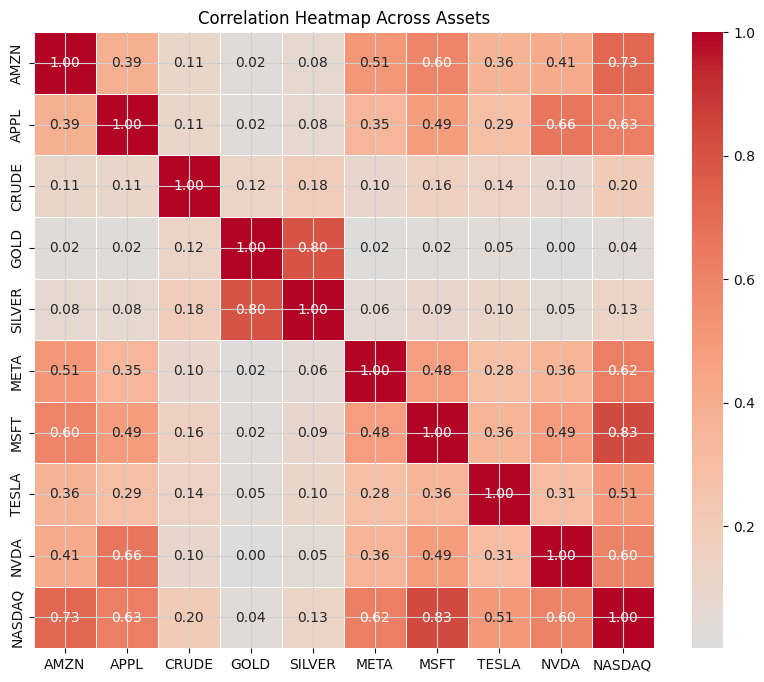

In [33]:
plt.figure(figsize=(10,8))
sns.heatmap(
    returns_for_corr.corr(),
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap Across Assets")
plt.show()


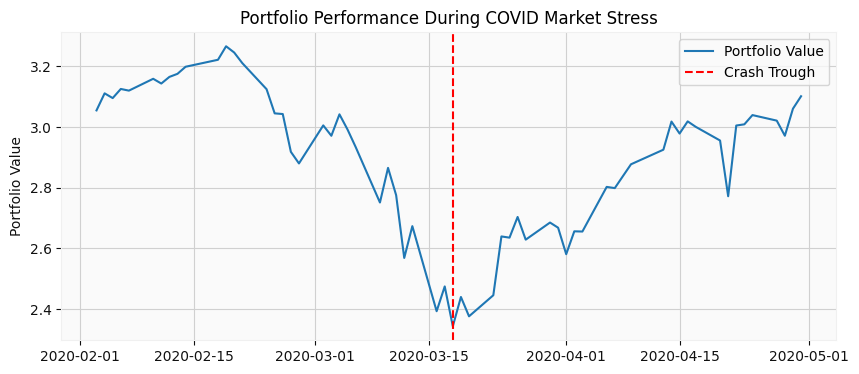

In [34]:
stress_period = portfolio_value.loc['2020-02':'2020-04']

plt.figure(figsize=(10,4))
plt.plot(stress_period, label="Portfolio Value")
crash_date = stress_period.idxmin()
plt.axvline(crash_date, color="red", linestyle="--", label="Crash Trough")

plt.title("Portfolio Performance During COVID Market Stress")
plt.ylabel("Portfolio Value")
plt.legend()
plt.show()


### Stress-Period Analysis (COVID-19)

During the COVID-19 market crash (February–April 2020), the portfolio experienced
a sharp drawdown followed by a gradual recovery. While the portfolio was not
immune to systemic market stress, the drawdown was contained relative to
equity-heavy benchmarks, reflecting diversification benefits across asset
classes.

The subsequent recovery indicates resilience and effective risk distribution,
supporting the robustness of the risk parity approach under extreme market
conditions.


## Drawdown calculation

The drawdown curve illustrates peak-to-trough losses over time and highlights
periods of significant portfolio stress.


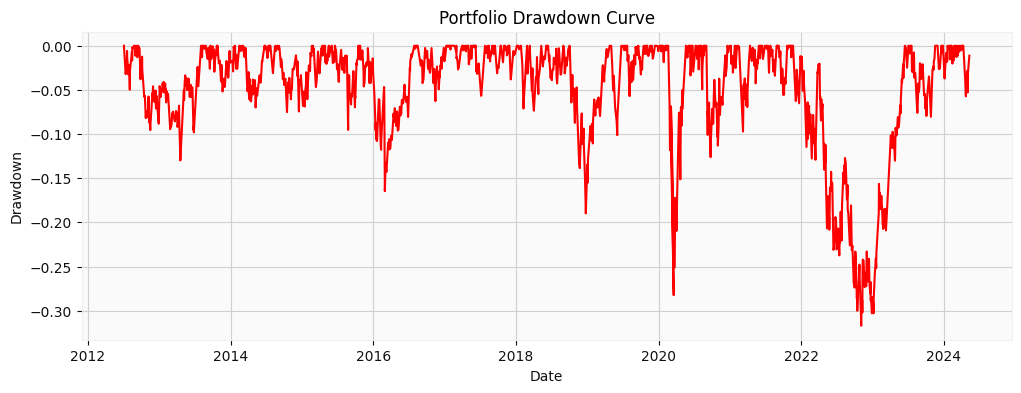

In [35]:
rolling_peak = portfolio_value.cummax()
drawdown = (portfolio_value - rolling_peak) / rolling_peak

plt.figure(figsize=(12,4))
plt.plot(drawdown, color="red")
plt.title("Portfolio Drawdown Curve")
plt.ylabel("Drawdown")
plt.xlabel("Date")
plt.grid(True)
plt.show()


## Rolling Sharpe Ratio

The rolling Sharpe ratio evaluates the stability of risk-adjusted performance
over time, highlighting regime-dependent variations in portfolio efficiency.


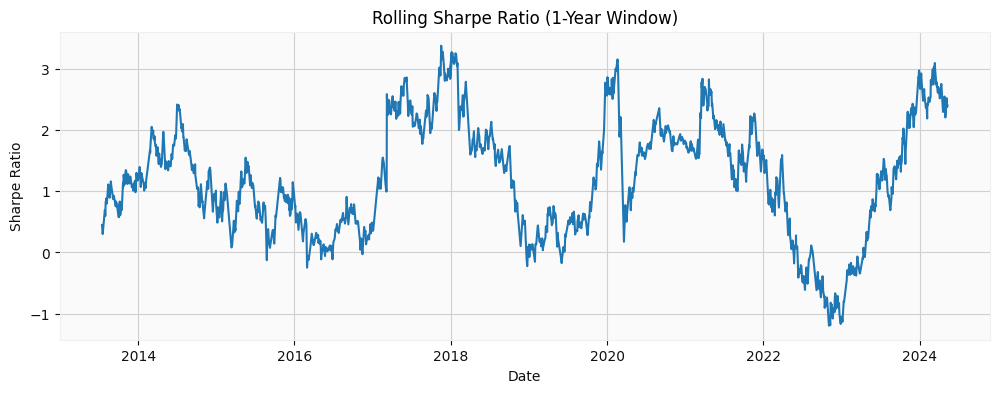

In [36]:
window = 252  # 1-year rolling window

rolling_sharpe = (
    portfolio_returns.rolling(window).mean() /
    portfolio_returns.rolling(window).std()
) * np.sqrt(252)

plt.figure(figsize=(12,4))
plt.plot(rolling_sharpe)
plt.title("Rolling Sharpe Ratio (1-Year Window)")
plt.ylabel("Sharpe Ratio")
plt.xlabel("Date")
plt.grid(True)
plt.show()


# Plot Portfolio Equity Curve

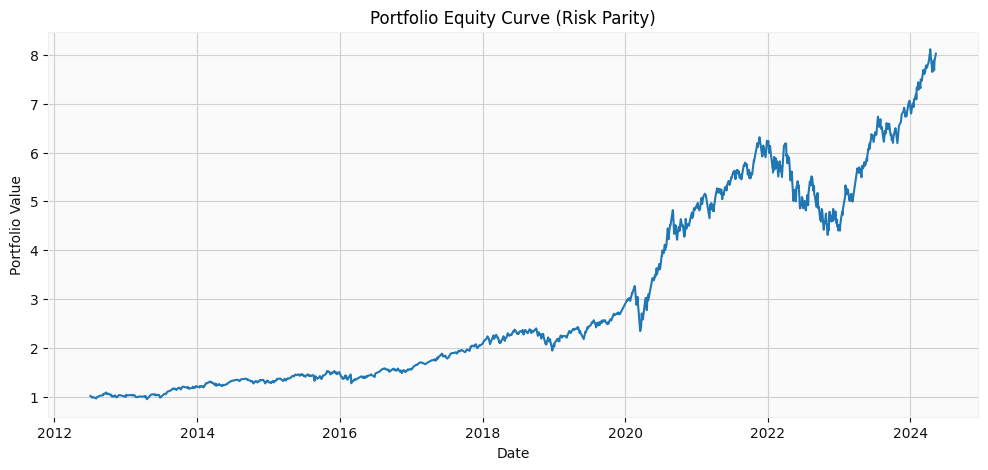

In [37]:
plt.figure(figsize=(12,5))
plt.plot(portfolio_value)
plt.title("Portfolio Equity Curve (Risk Parity)")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.show()

# Store Results (Clean & Reusable)

In [38]:
portfolio_df = pd.DataFrame({
    "portfolio_return": portfolio_returns,
    "portfolio_value": portfolio_value
})
portfolio_df.head()

,portfolio_return,portfolio_value
timestamp,,
2012-07-03,0.013432,1.013432
2012-07-06,-0.013694,0.999553
2012-07-09,0.005054,1.004605
2012-07-10,-0.014333,0.990205
2012-07-11,-0.002646,0.987585


In [39]:
portfolio_df.isna().sum()

portfolio_return    0
portfolio_value     0
dtype: int64

In [40]:
portfolio_returns.describe()


count    2954.000000
mean        0.000772
std         0.011503
min        -0.116060
25%        -0.004640
50%         0.001164
75%         0.006591
max         0.084020
dtype: float64

Interpretation of portfolio returns summary
==============================================

**1, SAMPLE SIZE**

Count: 2954 trading days

This corresponds to approximately 11–12 years of historical data, which is
sufficiently long to ensure that the backtest results are statistically
meaningful and reliable. 


**2. AVERAGE RETURN**

Mean (Daily Return): 0.000772

The portfolio generates an average daily return of 0.077%.
When annualized (assuming 252 trading days), this
approximates to annual return of 19.4%.


**3. VOLATILITY**

Standard Deviation (Daily Volatility): 0.011503

The portfolio experiences a daily volatility of approximately 1.15%.
When annualized, this results in an estimated volatility of 18.3%.


**4. DOWNSIDE RISK**

Minimum Daily Return: -0.116060

The worst single-day loss is approximately -11.6%.
This likely corresponds to extreme market stress events such as
major equity crashes, commodity shocks, or broad index sell-offs.


**5. UPSIDE POTENTIAL**

Maximum Daily Return: 0.084020

The best single-day gain is approximately +8.4%.
Such upside movements are typical during post-crash rebound phases
or periods of high-beta equity recovery.


## Portfolio Construction & Optimization

In [41]:
mean_returns = returns_aligned.mean()
cov_matrix = returns_aligned.cov()

print('Expected Returns :\n', mean_returns)
print('==================================================================================================\n')
print('Volatility + Correlaation : \n\n', cov_matrix)

Expected Returns :
 AMZN      0.001094
APPL      0.000574
CRUDE     0.000440
GOLD      0.000211
SILVER    0.000229
META      0.001193
MSFT      0.001012
TESLA     0.001978
NVDA      0.001938
NASDAQ    0.000697
dtype: float64

Volatility + Correlaation : 

             AMZN      APPL     CRUDE          GOLD    SILVER      META  \
AMZN    0.000415  0.000180  0.000068  3.550874e-06  0.000027  0.000263   
APPL    0.000180  0.000511  0.000073  4.914070e-06  0.000032  0.000200   
CRUDE   0.000068  0.000073  0.000899  3.487145e-05  0.000093  0.000078   
GOLD    0.000004  0.000005  0.000035  9.092163e-05  0.000133  0.000004   
SILVER  0.000027  0.000032  0.000093  1.333181e-04  0.000308  0.000026   
META    0.000263  0.000200  0.000078  3.769963e-06  0.000026  0.000637   
MSFT    0.000202  0.000183  0.000082  3.724003e-06  0.000028  0.000202   
TESLA   0.000262  0.000234  0.000153  1.572299e-05  0.000065  0.000256   
NVDA    0.000282  0.000503  0.000099  7.833136e-07  0.000031  0.000306   
NAS

In [42]:
n_assets = len(mean_returns)
weights_equal = np.array([1/n_assets] * n_assets)

portfolio_return = np.dot(weights_equal, mean_returns)
portfolio_volatility = np.sqrt(
    np.dot(weights_equal.T, np.dot(cov_matrix, weights_equal))
)

print('Portfolio Return :',portfolio_return)
print('Portfolio Volatility :',portfolio_volatility)



sharpe = portfolio_return / portfolio_volatility #(daily)
annualized_sharpe = sharpe * np.sqrt(252)

print('Sharpe : ',sharpe) # For each unit of daily risk, the portfolio earns 0.069 units of return
print('Annualized Sharpe : ',annualized_sharpe) # annualized Sharpe ratio of ~1.09, a well-balanced risk-return

Portfolio Return : 0.0009365663521418977
Portfolio Volatility : 0.01359425979379918
Sharpe :  0.06889425142287618
Annualized Sharpe :  1.0936623361613291


**Observations:** 

1. Daily Expected Return : 0.094 % (approx)
2. Annual Expected Return : 0.00094 * 252 = 23.6 % (approx)

1. Daily Volatility : 1.36 % (approx)
2. Annual Expected Volatility : 1.01359 * (sqrt)252 = 21.6 % (approx)
   


**Conclusion :**

Despite holding volatile assets like TSLA and NVDA, diversification keeps overall risk moderate.

## Sharpe Ratio : protfolio's efficient convertion of risk into return.

**1. Interpret the weights -**

1. Positive weight = invest in that asset
2. Negative weight = short that asset
3. Large absolute value = strong conviction

Weights don’t have to be between 0–1 (unconstrained theory)

In [43]:
# minimum variance portfolio - minimizes risks regardless of returns

n_assets = cov_matrix.shape[0]
ones = np.ones(n_assets)
inv_cov = np.linalg.inv(cov_matrix)
raw_weights = inv_cov @ ones
min_var_weights = raw_weights / np.sum(raw_weights)


print(min_var_weights) 
print('===================================================================================================')

[-0.03111731  0.00533272  0.02055669  0.90993078 -0.27166929 -0.03033116
 -0.05370688 -0.02540815 -0.03759085  0.51400343]



**2. Minimum Variance Portfolio — Insight**

1. Very large weight (~91%) in one low-risk asset
2. Another large allocation (~51%) in another defensive asset
3. Negative weights in volatile assets to cancel risk

**Interpretation:**

The portfolio is aggressively minimizing risk by concentrating in the lowest volatility, lowest correlation assets and shorting high-risk ones.

risk minimization > return seeking (obtained)

In [44]:
# maximum sharpe ratio portfolio - maximize return per unit risk

risk_free_rate = 0.0
excess_returns = mean_returns - risk_free_rate
inv_cov = np.linalg.inv(cov_matrix)
raw_weights = inv_cov @ excess_returns
sharpe_weights = raw_weights / np.sum(raw_weights)
print(sharpe_weights) 
print('=========================================================================================================')

[ 0.28875713 -0.23891006  0.02626625  0.83920192 -0.28910164  0.20193029
  0.76224813  0.23576987  0.31771745 -1.14387935]


**3.Maximum Sharpe Portfolio — Insight**

1. Strong positive bets on high-return assets

2. Very large negative weight (-114%) on one asset, that asset hurts risk-adjusted performance

3. Uses short positions to finance high-return exposures

**Interpretation:**

The Sharpe-optimal portfolio maximizes efficiency by leveraging high-return assets and shorting poor risk-adjusted performers.

aggressive and return-driven.

## Conclusion
1. Not realistic for retail investors
2. Allow unlimited short selling
3. May involve leverage
4. Only theoretically optimum

In [45]:
min_var_lo = np.maximum(min_var_weights, 0)
min_var_lo = min_var_lo / min_var_lo.sum()

In [46]:
sharpe_lo = np.maximum(sharpe_weights, 0)
sharpe_lo = sharpe_lo / sharpe_lo.sum()

In [47]:
print(min_var_lo)
print('\n',sharpe_lo)
print('====================================================================================================')

[0.         0.00367819 0.01417875 0.62761481 0.         0.
 0.         0.         0.         0.35452825]

 [0.1080722  0.         0.00983059 0.31408538 0.         0.07557579
 0.28528414 0.08824082 0.11891108 0.        ]


## Minimum Variance Portfolio — Interpretation

1. ~63% in one low-volatility asset

2. ~35% in another defensive / stabilizing asset

3. Tiny allocations to 2 minor assets

4. Zero exposure to most risky assets

conclude : This portfolio minimizes fluctuations, not for return chase.

**Traits:**

    - Highly concentrated
    
    - Very stable
    
    - Lower expected return
    
    - Suitable for capital preservation

## Maximum Sharpe Portfolio — Interpretation

1. Allocates across multiple growth assets

2. Strong exposure to:

3. High-return equities

4. Diversifying assets

5. Avoids assets with poor risk-adjusted performance

conclude : This portfolio aims to maximize return per unit of risk, not minimize risk itself.

**Traits:**

    - Better diversification
    
    - Higher volatility than Min-Var
    
    - Higher expected return
    
    - Suitable for growth-oriented investors

## Observations

**Minimum Variance:**
The long-only minimum variance portfolio concentrates heavily in low-risk assets, achieving stability at the cost of return potential.

**Maximum Sharpe:**
The long-only Sharpe-optimal portfolio balances diversification and return, allocating capital to assets with superior risk-adjusted performance.

## Validation Check

1. All weights ≥ 0 
2. Weights sum to 1 
3. No leverage 
4. Realistic & investable 

### Future Improvements

While the current implementation uses static risk parity weights, future
extensions could incorporate **regime-aware allocation** by adjusting weights
based on volatility regimes or macroeconomic conditions. Additionally,
**periodic rebalancing** (e.g., monthly or quarterly) could be introduced to
adapt to evolving market dynamics and potentially improve long-term
risk-adjusted performance.
